In [2]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#### Data Preprocessing: 

In [5]:
# Load dataset
data = pd.read_excel('/DataScinceExlr/Assignments/15. Clustering/EastWestAirlines.xlsx', sheet_name='data')

In [7]:
# load first few rows of the data
data.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [8]:
# get the feature informations
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


#### Data Preprocessing

In [9]:
data.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [10]:
# finding zeros in columns also checking the columns having valid zeros or not
(data == 0).sum()

ID#                     0
Balance                 1
Qual_miles           3773
cc1_miles               0
cc2_miles               0
cc3_miles               0
Bonus_miles           475
Bonus_trans           475
Flight_miles_12mo    2723
Flight_trans_12      2723
Days_since_enroll       0
Award?               2518
dtype: int64

#### These are the valid zero's in the columns no such column should be replace with median

#### There is no categorical data not required to do any encodeing

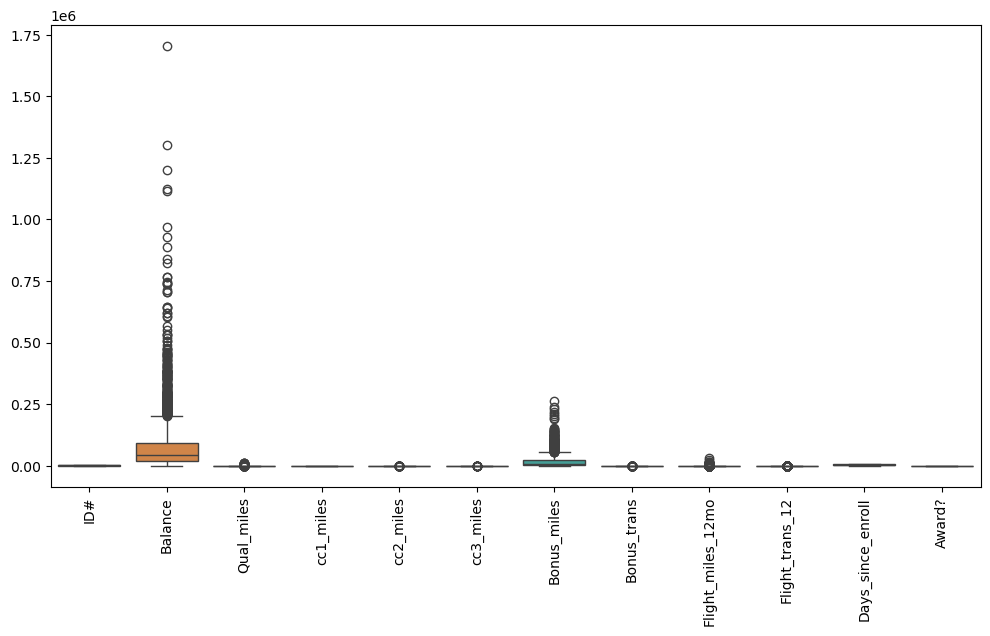

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.show()

In [12]:
'''
Balance and Bonus_miles are having outliers
'''

'\nBalance and Bonus_miles are having outliers\n'

In [13]:
# Scaling the data because clustering algorithms are distance-based
# Standardization ensures that all features contribute equally to distance calculations
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

In [14]:
'''
Feature scaling ensures that variables with larger scales do not disproportionately influence the model.
'''

'\nFeature scaling ensures that variables with larger scales do not disproportionately influence the model.\n'

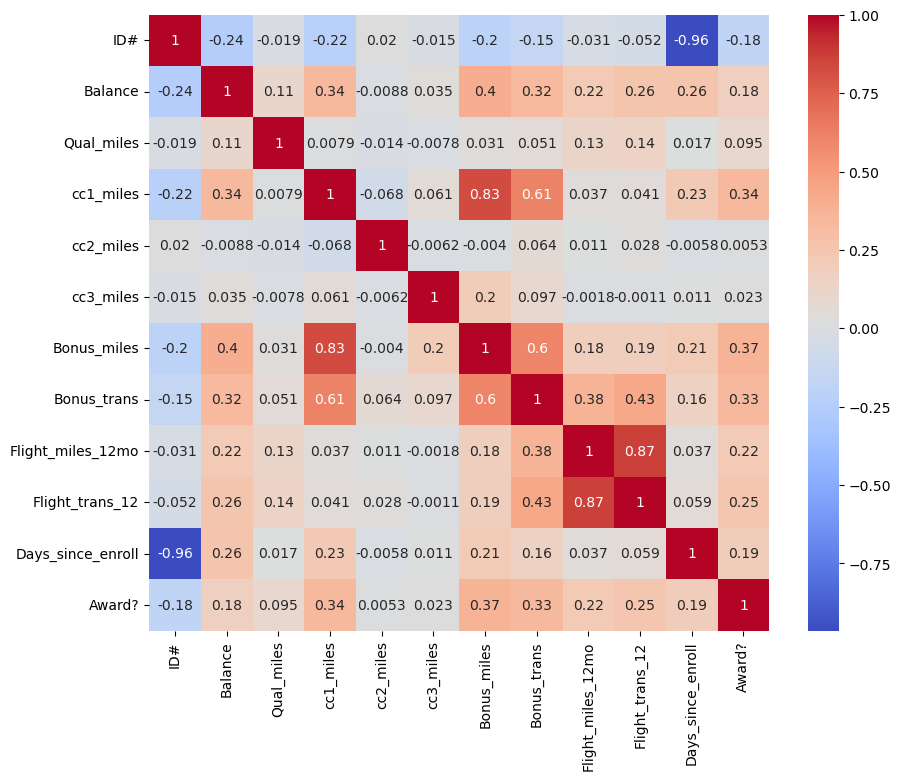

In [15]:
# Visualizing the correlation matrix to detect highly correlated features
# which may indicate redundancy in the dataset
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [16]:
'''
there is strong correlation between Bouns_miles, Bonus_trans and cc1_miles
'''

'\nthere is strong correlation between Bouns_miles, Bonus_trans and cc1_miles\n'

In [17]:
# Applying K-Means clustering and using the Elbow Method 
# to determine the optimal number of clusters

from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)   # Fit the model
    inertia.append(kmeans.inertia_)  # Store WCSS (inertia)

  File "C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


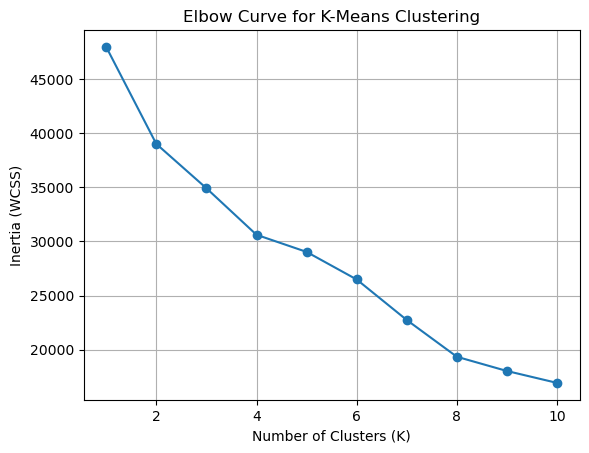

In [18]:
# Plotting the Elbow Curve to determine the optimal number of clusters (K)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Curve for K-Means Clustering')
plt.grid(True)
plt.show()

In [21]:
'''
The Elbow curve indicates a noticeable bend around K = 3 or 4,
suggesting diminishing returns in reducing inertia beyond this point. Hence, K = 3 was chosen as the optimal number of clusters.
'''

'\nThe Elbow curve indicates a noticeable bend around K = 3 or 4,\nsuggesting diminishing returns in reducing inertia beyond this point. Hence, K = 3 was chosen as the optimal number of clusters.\n'

In [22]:
# Applying K-Means clustering with the optimal number of clusters (K = 3)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

# Adding cluster labels to the original dataset
data['KMeans_Cluster'] = kmeans_labels

In [23]:
# Evaluating the clustering performance using Silhouette Score

from sklearn.metrics import silhouette_score

kmeans_silhouette = silhouette_score(scaled_data, kmeans_labels)
print("Silhouette Score (K-Means):", kmeans_silhouette)

Silhouette Score (K-Means): 0.201891717665419


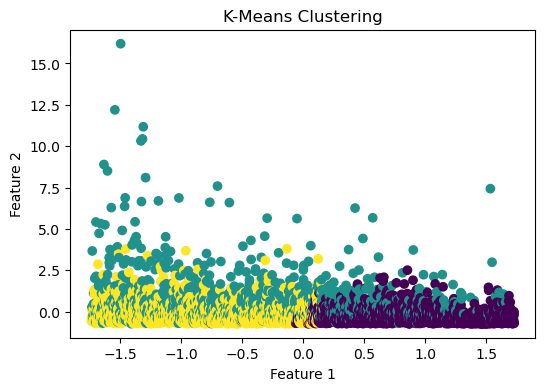

In [24]:
# Visualization of K-Means clusters (using first two features)

plt.figure(figsize=(6, 4))
plt.scatter(scaled_data[:, 0], scaled_data[:, 1],
            c=kmeans_labels, cmap='viridis')

plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [25]:
'''
The clusters are not distinctly separated; however, a certain degree of structure and grouping can be observed in the visualization.
'''

'\nThe clusters are not distinctly separated; however, a certain degree of structure and grouping can be observed in the visualization.\n'

In [26]:
# Applying DBSCAN clustering with chosen parameters (eps = 1.2, min_samples = 5)

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_data)

# Adding DBSCAN cluster labels to the dataset
data['DBSCAN_Cluster'] = dbscan_labels

In [27]:
data['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    2351
 1    1134
-1     488
 2      14
 3      12
Name: count, dtype: int64

In [28]:
'''
In DBSCAN, data points assigned the label -1 are considered noise or outliers. 
Unlike K-Means, DBSCAN automatically identifies noise points by detecting low-density regions in the dataset.
'''

'\nIn DBSCAN, data points assigned the label -1 are considered noise or outliers. \nUnlike K-Means, DBSCAN automatically identifies noise points by detecting low-density regions in the dataset.\n'

In [29]:
# Evaluating DBSCAN clustering using Silhouette Score
# (Excluding noise points labeled as -1)

mask = dbscan_labels != -1  # Filter out noise points

# Silhouette score can be calculated only if more than one cluster exists
if len(set(dbscan_labels[mask])) > 1:
    dbscan_silhouette = silhouette_score(scaled_data[mask], dbscan_labels[mask])
    print("Silhouette Score (DBSCAN):", dbscan_silhouette)
else:
    print("Silhouette Score cannot be calculated (only one cluster found)")

Silhouette Score (DBSCAN): 0.23700666640348614


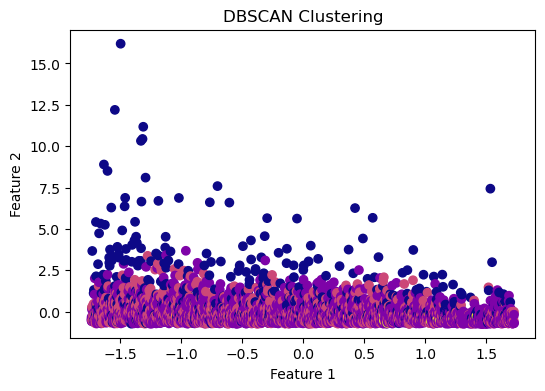

In [30]:
# Visualization of DBSCAN clustering (using first two features)

plt.figure(figsize=(6, 4))
plt.scatter(scaled_data[:, 0], scaled_data[:, 1],
            c=dbscan_labels, cmap='plasma')

plt.title('DBSCAN Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


---

## **Cluster Analysis and Interpretation**

### **K-Means Clustering**

* **Cluster 0:** Customers with high mileage and frequent flight activity, indicating loyal and high-value customers.
* **Cluster 1:** Customers with moderate flight activity and mileage balance, representing regular travelers.
* **Cluster 2:** Customers with low mileage balance and low activity, suggesting occasional or infrequent travelers.

K-Means provides clear segmentation by grouping customers based on similarity in travel behavior.

---

### **DBSCAN Clustering**

* DBSCAN identifies dense groups of customers based on data distribution.
* It automatically detects and separates noise or outlier points (labeled as -1).
* Compared to K-Means, DBSCAN is more robust to noise and does not require a predefined number of clusters.

---

### **Comparison**

* **K-Means** provides well-defined and interpretable customer segments.
* **DBSCAN** is effective in detecting outliers and handling noise in the dataset.
* While K-Means focuses on partitioning all data points into clusters, DBSCAN distinguishes between core clusters and noise points.

---

If you want, I can now give you a strong final **Conclusion section** that will make your assignment submission look top-level.
